In [24]:
# !pip install opencv-python matplotlib imutils tqdm ipywidgets scikit-learn

# **Imports**

In [25]:
import cv2 as cv
import matplotlib.pyplot as plt
import os
import imutils.paths as paths
import imutils
import pickle
import numpy as np
from tqdm.notebook import tqdm
import sklearn

In [26]:
print(os.getcwd())

c:\Users\joelr\repo\nexvisual-Visao_Computacional\Desafios\desafio_reconhecimento_facial


# **Processar a base de dados**

In [27]:
# Carregar os modelos.
protoPath = os.path.sep.join(["face_detection_model", "deploy.prototxt"])
modelPath = os.path.sep.join(["face_detection_model","res10_300x300_ssd_iter_140000.caffemodel"])
embedderPath = os.path.sep.join(["face_detection_model","openface_nn4.small2.v1.t7"])

detector = cv.dnn.readNetFromCaffe(protoPath, modelPath)
embedder = cv.dnn.readNetFromTorch(embedderPath)

# Captura os paths do dataset
imagePaths = list(paths.list_images("dataset"))

# Lista de caracteristicas e nomes
knownEmbeddings = []
knownNames = []


# loop sobre as imagens do dataset
for imagePath in tqdm(imagePaths):
    name = imagePath.split(os.path.sep)[-2] # Captura nomes dos dataset
    image = cv.imread(imagePath) # Le imagem
    image = imutils.resize(image, width=600) # Redimensiona imagem
    (h, w) = image.shape[:2] # Pega dimensões da imagem

    # OpenCV pre processamento para modelos de deep learning
    imageBlob = cv.dnn.blobFromImage(
        cv.resize(image, (300, 300)), 1.0, (300, 300),
        (104.0, 177.0, 123.0), swapRB=False, crop=False)
    detector.setInput(imageBlob) # Define entrada do modelo de deep learning
    detections = detector.forward() # Processa a imagem
	
    # Valida que pelo menos 1 face foi detectada na iamgem
    if len(detections) > 0:
        # Assumindo apenas 1 face por imagem, pegamos a maior bounding box
        # E validamos que aquela detecção está dentro do limite de 50% de confiança
        i = np.argmax(detections[0, 0, :, 2])
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5:
            # Calcular as coordenadas da bounding box
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            # Extrair a imagem da face
            face = image[startY:endY, startX:endX]
            (fH, fW) = face.shape[:2]
            # Valida que a imagem da face é grande o suficiente
            if fW < 20 or fH < 20:
                continue
            

            # OpenCV pre processamento para imagem da face
            faceBlob = cv.dnn.blobFromImage(face, 1.0 / 255,
                    (96, 96), (0, 0, 0), swapRB=True, crop=False)
            embedder.setInput(faceBlob) # Define como entrada do modelo de extração de características
            vec = embedder.forward() # Processa a imagem

            # Adiciona as listas o nome e as características
            knownNames.append(name)
            knownEmbeddings.append(vec.flatten())

# Salva arquivo.
data = {"embeddings": knownEmbeddings, "names": knownNames}
os.makedirs("output", exist_ok=True)
f = open("output/embeddings.pickle", "wb")
f.write(pickle.dumps(data))
f.close()

  0%|          | 0/21 [00:00<?, ?it/s]

# **Treinar o modelo de reconhecimento de face**

In [28]:
embeddingsPath = os.path.sep.join(["output", "embeddings.pickle"])
data = pickle.loads(open(embeddingsPath, "rb").read())


le = sklearn.preprocessing.LabelEncoder()
labels = le.fit_transform(data["names"])

recognizer = sklearn.svm.SVC(C=1.0, kernel="linear", probability=True)
recognizer.fit(data["embeddings"], labels)

# Salva os modelos de classificação e de labels
f = open(r"output\recognizer.pickle", "wb")
f.write(pickle.dumps(recognizer))
f.close()
f = open(r"output\le.pickle", "wb")
f.write(pickle.dumps(le))
f.close()

# **Validar o modelo**

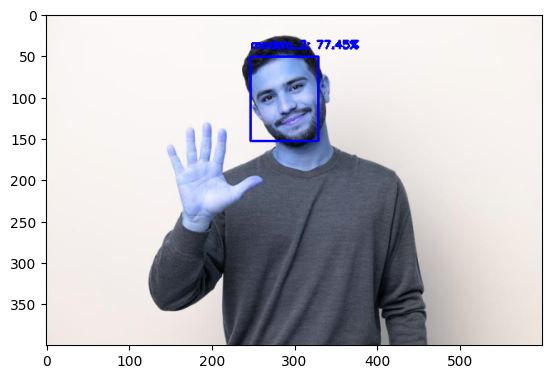

In [31]:
# Imagem para o teste
image_to_test_path = r"test\modelo_2_1.jpeg"

# Carregamento dos modelos
protoPath = os.path.sep.join(["face_detection_model", "deploy.prototxt"])
modelPath = os.path.sep.join(["face_detection_model", "res10_300x300_ssd_iter_140000.caffemodel"])
embedderPath = os.path.sep.join(["face_detection_model","openface_nn4.small2.v1.t7"])
recognizerPath = os.path.sep.join(["output", "recognizer.pickle"])
lePath = os.path.sep.join(["output", "le.pickle"])

detector = cv.dnn.readNetFromCaffe(protoPath, modelPath)
embedder = cv.dnn.readNetFromTorch(embedderPath)
recognizer = pickle.loads(open(recognizerPath, "rb").read())
le = pickle.loads(open(lePath, "rb").read())

# Carrega a imagem
image = cv.imread(image_to_test_path)
image = imutils.resize(image, width=600)
(h,w) = image.shape[:2]
imageBlob = cv.dnn.blobFromImage(
    image,
    scalefactor=1.0,
    size=(300,300),
    mean=(104.0, 177.0, 123.0),
    swapRB=False,
    crop=False
)
detector.setInput(imageBlob)
detections = detector.forward()


for i in range(0, detections.shape[2]):
    confidence = detections[0, 0, i, 2]
    if confidence > 0.5:
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")
        
        face = image[startY:endY, startX:endX]
        (fH,fW) = face.shape[:2]
        if fW < 20 or fH < 20:
            continue
    
        faceBlob = cv.dnn.blobFromImage(
            face,
            scalefactor=1.0 / 255,
            size=(96,96),
            mean=(0, 0, 0),
            swapRB=True,
            crop=False

        )

        embedder.setInput(faceBlob)
        vec = embedder.forward()

        preds = recognizer.predict_proba(vec)[0]
        j = np.argmax(preds)
        proba = preds[j]
        name = le.classes_[j]

        text = "{}: {:.2f}%".format(name, proba*100)
        y = startY - 10 if startY - 10 > 10 else startY + 10
        cv.rectangle(image, (startX, startY), (endX, endY), (0,0,255), 2)
        cv.putText(image, text, (startX, y), cv.FONT_HERSHEY_SIMPLEX, 0.45, (0,0,255), 2)

        plt.imshow(image)